In [ ]:
import pandas as pd

train = pd.read_csv("../../Data/train_transaction.csv") # ,nrows=10000)
# checking the shape of the data 
Row_count = len(train)
missing_count = train.isna().sum()
missing_percent = train.isna().mean() *100

missing_summary = pd.DataFrame({
    "Column_name":missing_count.index,
    "Row_count" : Row_count,
    "missing_count": missing_count.values,
    "missing_percent": missing_percent.values
})

missing_summary = missing_summary.sort_values("missing_percent",ascending=False)
missing_summary.head(20)

# is there any coulmn with more than 90% missing values, so that we can drop unnecessart coulmns 
high_missing = missing_summary[missing_summary["missing_percent"] > 90]


# checking the Fraud transaction counts, is it imbalanced dataset or not 
train["isFraud"].value_counts()
train["isFraud"].value_counts(normalize=True) * 100
#isFraud
#0    96.500999
#1     3.499001 


# checking the missing values in dist2 column, and how many of them are fraud transactions
train.groupby(train["dist2"].isna())["isFraud"].agg(["count", "sum", "mean"])

# checking the missing values in D7 column, and how many of them are fraud transactions
train.groupby(train["D7"].isna())["isFraud"].agg(["count", "sum", "mean"])




,count,sum,mean
D7,,,
False,38917,5790,0.148778
True,551623,14873,0.026962


In [3]:
# discribe the missing values in all the columns

missing_summary = pd.DataFrame({
    "Column_name": train.columns,
    "missing_count": train.isna().sum().values,
    "missing_percent": (train.isna().mean() * 100).values
})


missing_summary["missing_percent"].describe()

count    394.000000
mean      41.073431
std       35.895976
min        0.000000
25%        0.214888
50%       28.612626
75%       77.913435
max       93.628374
Name: missing_percent, dtype: float64

In [ ]:
# Missing classification based on the missing percentage 

missing_summary[ missing_summary["missing_percent"] == 0].shape
#(20, 3)

missing_summary[
    (missing_summary["missing_percent"] >0) &
    (missing_summary["missing_percent"] < 50)
    ].shape
#(200, 3)

missing_summary[missing_summary["missing_percent"] > 50].shape
# (174, 3)

missing_summary[missing_summary["missing_percent"] > 80].shape
# (55, 3)




(55, 3)

In [5]:
# Missing vs Fraud analysis

# create a function (1) where the df is the dataframe (train)

def missing_vs_fraud(df, column):
    result = df.groupby(
        df[column].isna()
    )["isFraud"].agg(["count", "sum", "mean"])
    
    return result

# ------------------------------
# loop through all the columns in the (train) dataset
results = []

for column in train.columns:
    if column == "isFraud":
        continue
    
    result = missing_vs_fraud(train, column)
    
    fraud_missing = result.loc[True, "mean"] if True in result.index else None
    fraud_available = result.loc[False, "mean"] if False in result.index else None
    
    results.append({
        "Column": column,
        "% Missing": train[column].isna().mean() * 100,
        "Fraud Rate - Missing": fraud_missing * 100 if fraud_missing is not None else None,
        "Fraud Rate - Available": fraud_available * 100 if fraud_available is not None else None
    })


missing_fraud_analysis = pd.DataFrame(results)
missing_fraud_analysis.head(20)


,Column,% Missing,Fraud Rate - Missing,Fraud Rate - Available
0,TransactionID,0.000000,NaN,3.499001
1,TransactionDT,0.000000,NaN,3.499001
2,TransactionAmt,0.000000,NaN,3.499001
3,ProductCD,0.000000,NaN,3.499001
4,card1,0.000000,NaN,3.499001
5,card2,1.512683,4.735251,3.480013
6,card3,0.265012,2.492013,3.501677
7,card4,0.267044,2.599873,3.501408
8,card5,0.721204,4.930735,3.488600
9,card6,0.266028,2.482495,3.501712


In [ ]:
# the correlation between the mising valus and the fraud rate
missing_fraud_analysis["Fraud Rate Difference"] = (
    missing_fraud_analysis["Fraud Rate - Available"]
    - missing_fraud_analysis["Fraud Rate - Missing"]
)

missing_fraud_analysis.sort_values("Fraud Rate Difference",ascending=True).head(20)




,Column,% Missing,Fraud Rate - Missing,Fraud Rate - Available,Fraud Rate Difference
370,V317,0.002032,16.666667,3.498733,-13.167933
369,V316,0.002032,16.666667,3.498733,-13.167933
372,V319,0.002032,16.666667,3.498733,-13.167933
365,V312,0.002032,16.666667,3.498733,-13.167933
363,V310,0.002032,16.666667,3.498733,-13.167933
371,V318,0.002032,16.666667,3.498733,-13.167933
374,V321,0.002032,16.666667,3.498733,-13.167933
373,V320,0.002032,16.666667,3.498733,-13.167933
361,V308,0.002032,16.666667,3.498733,-13.167933
364,V311,0.002032,16.666667,3.498733,-13.167933


In [ ]:
#Data Quality: Duplicates

# is there any duplicate rows in the dataset
train.duplicated().sum()
duplicate_rows = train.duplicated().sum()
duplicate_percent = duplicate_rows / len(train) * 100

print("Duplicate rows:", duplicate_rows)
print("% Duplicate:", duplicate_percent)

#---------------------

# is there any duplicates in the TransactionID column
train["TransactionID"].duplicated().sum()
duplicate_transaction_ids = train["TransactionID"].duplicated().sum()

print("Duplicate TransactionIDs:", duplicate_transaction_ids)




In [ ]:
# Data Validity Checks

# is there any negative values in the Amount
train[["TransactionAmt", "TransactionDT"]].describe()


# checking for negative values in numeric columns
negative_values = (train.select_dtypes(include="number") < 0).sum()
negative_values = negative_values[negative_values > 0]

negative_values


train.loc[
    train[["D4", "D6", "D11", "D12", "D14", "D15"]].lt(0).any(axis=1),["D4", "D6", "D11", "D12", "D14", "D15", "isFraud"]
]

# checking for the zero values in numeric columns
zero_values = (train.select_dtypes(include="number") == 0).sum()
zero_values = zero_values[zero_values > 0]
zero_values



In [ ]:
# data type of each coulmn

column_profile = pd.DataFrame({
    "Column": train.columns,
    "Data_Type": train.dtypes.astype(str),
    "Unique_Count": train.nunique(dropna=True)
})

def classify_column(row):
    col = row["Column"]
    dtype = row["Data_Type"]
    if col in ["TransactionID", "TransactionDT"]:
        return "Identifier / Time"
    elif dtype in ["object", "string"]:
        return "Categorical"
    elif row["Unique_Count"] <= 20:
        return "Categorical / Low Cardinality"
    else:
        return "Numerical"

column_profile["Category"] = column_profile.apply(classify_column, axis=1)
column_profile

,Column,Data_Type,Unique_Count,Category
TransactionID,TransactionID,int64,590540,Identifier / Time
isFraud,isFraud,int64,2,Categorical / Low Cardinality
TransactionDT,TransactionDT,int64,573349,Identifier / Time
TransactionAmt,TransactionAmt,float64,20902,Numerical
ProductCD,ProductCD,str,5,Categorical / Low Cardinality
...,...,...,...,...
V335,V335,float64,672,Numerical
V336,V336,float64,356,Numerical
V337,V337,float64,254,Numerical
V338,V338,float64,380,Numerical


In [ ]:
# Train Identity 

train_identity = pd.read_csv("../../Data/train_identity.csv")
train_identity.head()


#print("Shape:", train_identity.shape)
# Shape: (144233, 41)

#train_identity.info()

duplicate_rows2 = train_identity.duplicated().sum()
duplicate_percent2 = duplicate_rows / len(train_identity) * 100

print("Duplicate rows:", duplicate_rows2)
print("Duplicate %:", duplicate_percent2)

#---------------------

# is there any duplicates in the TransactionID column
train_identity["TransactionID"].duplicated().sum()
duplicate_transaction_ids2 = train_identity["TransactionID"].duplicated().sum()

print("Duplicate TransactionIDs:", duplicate_transaction_ids2)




In [ ]:
# Merge

train_merged = train.merge(
    train_identity,
    on="TransactionID",
    how="left"
)

print(train.shape)
print(train_identity.shape)
print(train_merged.shape)



In [ ]:
#  Fraud VS Non-Fraud

import matplotlib.pyplot as plt

#exploring the distribution of the Fraud transactions in the dataset
fraud_counts = train_merged["isFraud"].value_counts()

# %
fraud_percent = train_merged["isFraud"].value_counts(normalize=True) * 100

fraud_summary = pd.DataFrame({"Count": fraud_counts, "Percent": fraud_percent})

fraud_summary.index = ["Non-Fraud", "Fraud"]
print(fraud_summary)
plt.figure(figsize=(5, 4))

plt.bar(fraud_summary.index,fraud_summary["Percent"])

plt.title("Transaction Distribution: Fraud vs Non-Fraud")
plt.xlabel("Tran Type")
plt.ylabel("NO. of Transactions")
plt.show()


           Transaction_Count  Fraud_Rate_%
ProductCD                                 
C                      68519     11.687269
S                      11628      5.899553
H                      33024      4.766231
R                      37699      3.782594
W                     439670      2.039939


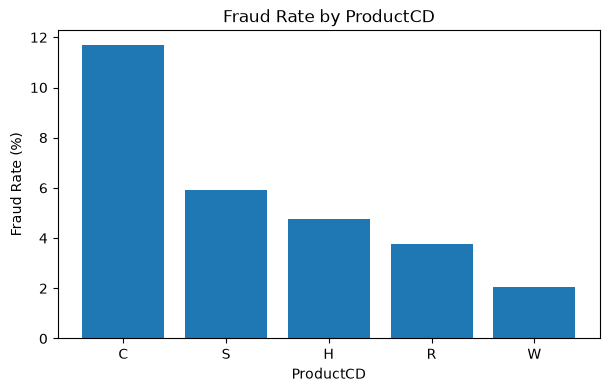

In [ ]:
# EDA - % Fraud in each product cat

product_counts = train_merged["ProductCD"].value_counts()

# % Fraud per Product CD
fraud_rate = train_merged.groupby("ProductCD")["isFraud"].mean() * 100

# The product C has the higest Fraud rate 

product_summary = pd.DataFrame({
    "Transaction_Count": product_counts,
    "Fraud_Rate_%": fraud_rate
}).sort_values("Fraud_Rate_%", ascending=False)

print(product_summary)

plt.figure(figsize=(7, 4))
plt.bar(product_summary.index,product_summary["Fraud_Rate_%"])

plt.title("Fraud Rate by ProductCD")
plt.xlabel("ProductCD")
plt.ylabel("Fraud Rate (%)")

plt.show()

In [ ]:
# % Fraud by amount

amount_summary = train_merged.groupby("isFraud")["TransactionAmt"].describe()
amount_summary.index = ["Non-Fraud", "Fraud"]
print(amount_summary)


In [ ]:
# EDA - Fraud by Hour

train_merged["TransactionHour"] = (train_merged["TransactionDT"] // 3600) % 24


train_merged["TransactionDay"] = (train_merged["TransactionDT"] // (24 * 3600))

hourly_fraud = (
    train_merged
    .groupby("TransactionHour")["isFraud"].agg(
        Transaction_Count="count",
        Fraud_Count="sum",
        Fraud_Rate="mean"
    )
)

hourly_fraud["Fraud_Rate"] *= 100

hourly_fraud

# the hieghest fraud rate is between 5-9 AM

,Transaction_Count,Fraud_Count,Fraud_Rate
TransactionHour,,,
0,37795,1186,3.137981
1,32797,1027,3.131384
2,26732,1002,3.748317
3,20802,797,3.831362
4,14839,770,5.189029
5,9701,682,7.030203
6,6007,467,7.774263
7,3704,393,10.610151
8,2591,241,9.301428


In [ ]:
# EDA - Fraud bu device type
device_fraud = (
    train_merged
    .groupby("DeviceType")["isFraud"] .agg(
        Transaction_Count="count",
        Fraud_Count="sum",
        Fraud_Rate="mean"
    )
)

device_fraud["Fraud_Rate"] *= 100

device_fraud

,Transaction_Count,Fraud_Count,Fraud_Rate
DeviceType,,,
desktop,85165,5554,6.521458
mobile,55645,5657,10.166232


In [ ]:
# EDA - does the transaction have idinitiy information or not, and how it affects the fraud rate 

train_merged["HasIdentity"] = train_merged["TransactionID"].isin(train_identity["TransactionID"])

identity_fraud = (
    train_merged
    .groupby("HasIdentity")["isFraud"].agg(
        Transaction_Count="count",
        Fraud_Count="sum",
        Fraud_Rate="mean"
    )
)

identity_fraud["Fraud_Rate"] *= 100
identity_fraud


#Transactions with available identity information have a substantially higher observed fraud rate 
# (7.85%) compared with transactions without identity information  (2.09%).


,Transaction_Count,Fraud_Count,Fraud_Rate
HasIdentity,,,
False,446307,9345,2.093850
True,144233,11318,7.847025
